In [239]:
import pandas as pd
import numpy as np

train = pd.read_csv('/Users/proudchris/Desktop/ML_modeling/Sparta/data/train.csv')
test = pd.read_csv('/Users/proudchris/Desktop/ML_modeling/Sparta/data/test.csv')
submission = pd.read_csv('/Users/proudchris/Desktop/ML_modeling/Sparta/data/sampleSubmission.csv')

In [240]:
train.shape, test.shape

((10886, 12), (6493, 9))

In [241]:
train

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [242]:
test

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


In [243]:
submission

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0
...,...,...
6488,2012-12-31 19:00:00,0
6489,2012-12-31 20:00:00,0
6490,2012-12-31 21:00:00,0
6491,2012-12-31 22:00:00,0


In [244]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [245]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   str    
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), str(1)
memory usage: 456.7 KB


In [246]:
print(train['datetime'][100].split()[0])
print(train['datetime'][100].split()[0].split('-'))
print(train['datetime'][100].split()[0].split('-')[0])
print(train['datetime'][100].split()[0].split('-')[1])
print(train['datetime'][100].split()[0].split('-')[2])

2011-01-05
['2011', '01', '05']
2011
01
05


In [247]:
print(train['datetime'][100].split()[1])
print(train['datetime'][100].split()[1].split(':'))
print(train['datetime'][100].split()[1].split(':')[0])
print(train['datetime'][100].split()[1].split(':')[1])
print(train['datetime'][100].split()[1].split(':')[2])

09:00:00
['09', '00', '00']
09
00
00


In [248]:
train['date'] = train['datetime'].apply(lambda x: x.split()[0])

train['year'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[0])
train['month'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[1])
train['day'] = train['datetime'].apply(lambda x: x.split()[0].split('-')[2])

train['hour'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[0])
train['minute'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[1])
train['second'] = train['datetime'].apply(lambda x: x.split()[1].split(':')[2])

In [249]:
from datetime import datetime
import calendar

print(train['date'][100])
print(datetime.strptime(train['date'][100], '%Y-%m-%d'))

print(datetime.strptime(train['date'][100], '%Y-%m-%d').weekday())

print(calendar.day_name[datetime.strptime(train['date'][100], '%Y-%m-%d').weekday()])

train['weekday'] = train['date'].apply(lambda dateString: calendar.day_name[datetime.strptime(dateString, "%Y-%m-%d").weekday()])

2011-01-05
2011-01-05 00:00:00
2
Wednesday


In [250]:
train['season'] = train['season'].map({1: 'Spring', 
                                       2:'Summer', 
                                       3: 'Fall', 
                                       4: 'Winter'})

train['weather'] = train['weather'].map({1: 'Clear', 2: 'Mist, Few clouds', 3: 'Light Snow, Rain, Thunderstorm', 4: 'Heavy Rain, Thunderstrom, Snow, Fog'})

In [251]:
train

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,year,month,day,hour,minute,second,weekday
0,2011-01-01 00:00:00,Spring,0,0,Clear,9.84,14.395,81,0.0000,3,13,16,2011-01-01,2011,01,01,00,00,00,Saturday
1,2011-01-01 01:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0000,8,32,40,2011-01-01,2011,01,01,01,00,00,Saturday
2,2011-01-01 02:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0000,5,27,32,2011-01-01,2011,01,01,02,00,00,Saturday
3,2011-01-01 03:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0000,3,10,13,2011-01-01,2011,01,01,03,00,00,Saturday
4,2011-01-01 04:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0000,0,1,1,2011-01-01,2011,01,01,04,00,00,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0,1,Clear,15.58,19.695,50,26.0027,7,329,336,2012-12-19,2012,12,19,19,00,00,Wednesday
10882,2012-12-19 20:00:00,Winter,0,1,Clear,14.76,17.425,57,15.0013,10,231,241,2012-12-19,2012,12,19,20,00,00,Wednesday
10883,2012-12-19 21:00:00,Winter,0,1,Clear,13.94,15.910,61,15.0013,4,164,168,2012-12-19,2012,12,19,21,00,00,Wednesday
10884,2012-12-19 22:00:00,Winter,0,1,Clear,13.94,17.425,61,6.0032,12,117,129,2012-12-19,2012,12,19,22,00,00,Wednesday


In [252]:
import seaborn as sns 
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

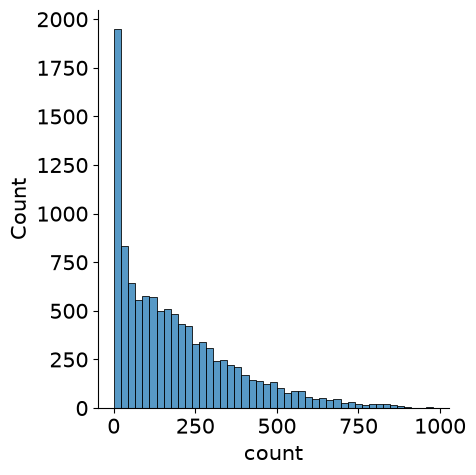

In [253]:
mpl.rc('font', size=15)
sns.displot(train['count']);

## 회귀 모델이 좋은 성능을 내려면 데이터가 정규분포를 따라야한다. 

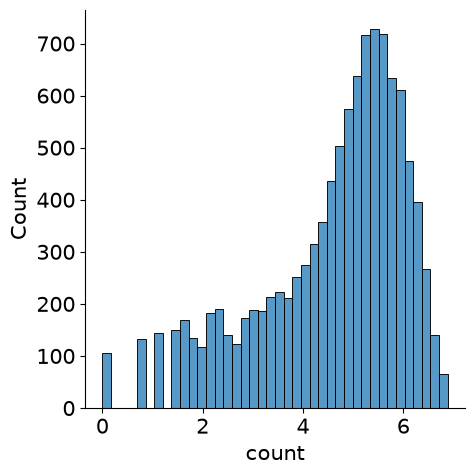

In [254]:
sns.displot(np.log(train['count']));

<Axes: xlabel='second', ylabel='count'>

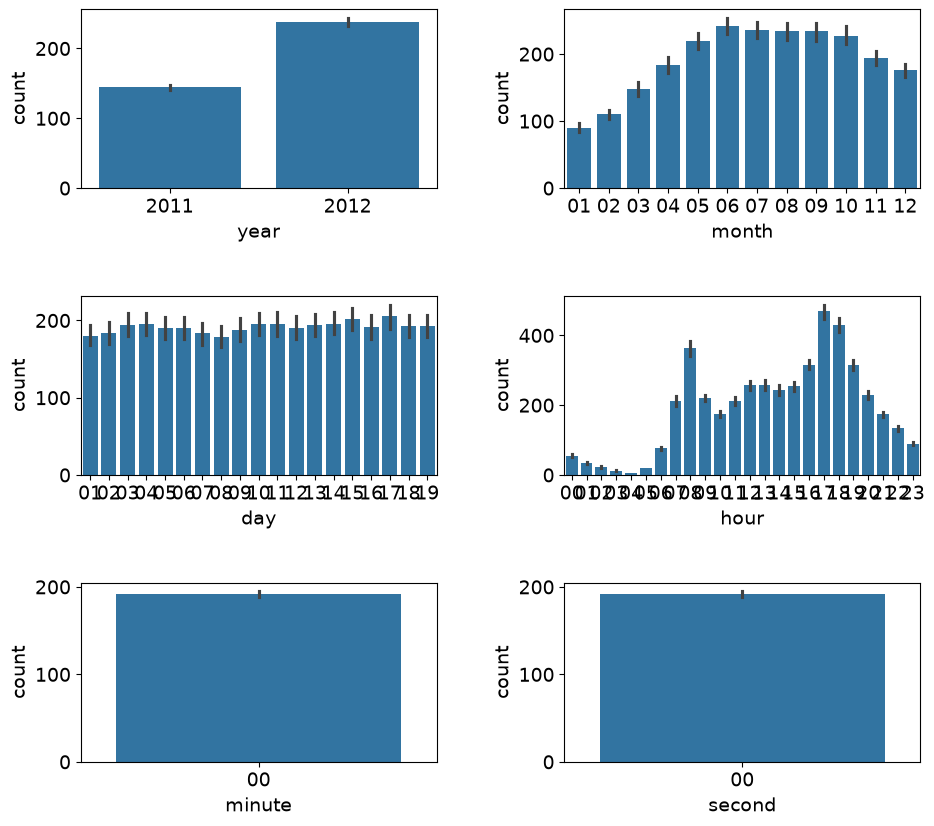

In [255]:
mpl.rc('font', size=14)
mpl.rc('axes', titlesize=15)

figure, axes = plt.subplots(nrows=3, ncols=2)
plt.tight_layout()

plt.tight_layout()
figure.set_size_inches(10, 9)


sns.barplot(x='year', y='count', data=train, ax=axes[0, 0])
sns.barplot(x='month', y='count', data=train, ax=axes[0, 1])
sns.barplot(x='day', y='count', data=train, ax=axes[1, 0])
sns.barplot(x='hour', y='count', data=train, ax=axes[1, 1])
sns.barplot(x='minute', y='count', data=train, ax=axes[2, 0])
sns.barplot(x='second', y='count', data=train, ax=axes[2, 1])



In [256]:
train = train[train['weather'] != 4]

In [257]:
all_data = pd.concat([train, test], ignore_index=True)
all_data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,year,month,day,hour,minute,second,weekday
0,2011-01-01 00:00:00,Spring,0,0,Clear,9.84,14.395,81,0.0000,3.0,13.0,16.0,2011-01-01,2011,01,01,00,00,00,Saturday
1,2011-01-01 01:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0000,8.0,32.0,40.0,2011-01-01,2011,01,01,01,00,00,Saturday
2,2011-01-01 02:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0000,5.0,27.0,32.0,2011-01-01,2011,01,01,02,00,00,Saturday
3,2011-01-01 03:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0000,3.0,10.0,13.0,2011-01-01,2011,01,01,03,00,00,Saturday
4,2011-01-01 04:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0000,0.0,1.0,1.0,2011-01-01,2011,01,01,04,00,00,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17375,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17376,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17377,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [258]:


all_data['date'] = all_data['datetime'].apply(lambda x: x.split()[0])
all_data['year'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[0])
all_data['month'] = all_data['datetime'].apply(lambda x: x.split()[0].split('-')[1])
all_data['hour'] = all_data['datetime'].apply(lambda x: x.split()[1].split(':')[0])

all_data['week'] = all_data['date'].apply(lambda dateString: datetime.strptime(dateString, "%Y-%m-%d").weekday())

all_data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,count,date,year,month,day,hour,minute,second,weekday,week
0,2011-01-01 00:00:00,Spring,0,0,Clear,9.84,14.395,81,0.0000,3.0,...,16.0,2011-01-01,2011,01,01,00,00,00,Saturday,5
1,2011-01-01 01:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0000,8.0,...,40.0,2011-01-01,2011,01,01,01,00,00,Saturday,5
2,2011-01-01 02:00:00,Spring,0,0,Clear,9.02,13.635,80,0.0000,5.0,...,32.0,2011-01-01,2011,01,01,02,00,00,Saturday,5
3,2011-01-01 03:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0000,3.0,...,13.0,2011-01-01,2011,01,01,03,00,00,Saturday,5
4,2011-01-01 04:00:00,Spring,0,0,Clear,9.84,14.395,75,0.0000,0.0,...,1.0,2011-01-01,2011,01,01,04,00,00,Saturday,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,...,NaN,2012-12-31,2012,12,NaN,19,NaN,NaN,NaN,0
17375,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,NaN,...,NaN,2012-12-31,2012,12,NaN,20,NaN,NaN,NaN,0
17376,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,NaN,...,NaN,2012-12-31,2012,12,NaN,21,NaN,NaN,NaN,0
17377,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,NaN,...,NaN,2012-12-31,2012,12,NaN,22,NaN,NaN,NaN,0


In [259]:
drop_features = ['casual', 'registered', 'datetime', 'date', 'month', 'windspeed']

all_data = all_data.drop(drop_features, axis=1)

all_data

,season,holiday,workingday,weather,temp,atemp,humidity,count,year,day,hour,minute,second,weekday,week
0,Spring,0,0,Clear,9.84,14.395,81,16.0,2011,01,00,00,00,Saturday,5
1,Spring,0,0,Clear,9.02,13.635,80,40.0,2011,01,01,00,00,Saturday,5
2,Spring,0,0,Clear,9.02,13.635,80,32.0,2011,01,02,00,00,Saturday,5
3,Spring,0,0,Clear,9.84,14.395,75,13.0,2011,01,03,00,00,Saturday,5
4,Spring,0,0,Clear,9.84,14.395,75,1.0,2011,01,04,00,00,Saturday,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,0,1,2,10.66,12.880,60,NaN,2012,NaN,19,NaN,NaN,NaN,0
17375,1,0,1,2,10.66,12.880,60,NaN,2012,NaN,20,NaN,NaN,NaN,0
17376,1,0,1,1,10.66,12.880,60,NaN,2012,NaN,21,NaN,NaN,NaN,0
17377,1,0,1,1,10.66,13.635,56,NaN,2012,NaN,22,NaN,NaN,NaN,0


In [260]:
X_train = all_data[~pd.isnull(all_data['count'])]
X_test = all_data[pd.isnull(all_data['count'])]

X_train = X_train.drop(['count'], axis=1)
X_test = X_test.drop(['count'], axis=1)

y = train['count']

In [261]:
X_train

,season,holiday,workingday,weather,temp,atemp,humidity,year,day,hour,minute,second,weekday,week
0,Spring,0,0,Clear,9.84,14.395,81,2011,01,00,00,00,Saturday,5
1,Spring,0,0,Clear,9.02,13.635,80,2011,01,01,00,00,Saturday,5
2,Spring,0,0,Clear,9.02,13.635,80,2011,01,02,00,00,Saturday,5
3,Spring,0,0,Clear,9.84,14.395,75,2011,01,03,00,00,Saturday,5
4,Spring,0,0,Clear,9.84,14.395,75,2011,01,04,00,00,Saturday,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,Winter,0,1,Clear,15.58,19.695,50,2012,19,19,00,00,Wednesday,2
10882,Winter,0,1,Clear,14.76,17.425,57,2012,19,20,00,00,Wednesday,2
10883,Winter,0,1,Clear,13.94,15.910,61,2012,19,21,00,00,Wednesday,2
10884,Winter,0,1,Clear,13.94,17.425,61,2012,19,22,00,00,Wednesday,2


In [262]:
def rmsle(y_true, y_pred, convertExp=True):
    if convertExp:
        y_true = np.exp(y_true)
        y_pred = np.exp(y_pred)

    log_true = np.nan_to_num(np.log(y_true+1))
    log_pred = np.nan_to_num(np.log(y_pred+1))

    output = np.sqrt(np.mean((log_true - log_pred)**2))

    return output

In [263]:
from sklearn.linear_model import LinearRegression

linear_reg_model = LinearRegression()

In [264]:
log_y = np.log(y)
linear_reg_model.fit(X_train, log_y)

ValueError: could not convert string to float: 'Spring'